In [1]:
from maskvar.datasets.coco_lvis import LvisDataset
from maskvar.datasets.hqseg44k import HQSeg44KTrainDataset, HQSeg44KTestDataset
from maskvar.datasets.mask_level_dataset import MaskLevelDatasetRandom
from maskvar.datasets import instance_info
from maskvar.datasets import CoconutHFDataset

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from itertools import islice

from torchvision.utils import make_grid

In [2]:
# datasets = LvisDataset(
#     dataset_path='data/coco_lvis',
#     split='val',
#     img_split='val',
#     stuff_prob=0.0,
# )
# dataset = HQSeg44KTrainDataset(
#     data_root='../data/sam-hq',
#     img_size=(512, 512)
# )
dataset = CoconutHFDataset(
    parquet_path="../data/coconut/val",
    image_root="../data/coconut/val2017",
)

Loaded 5000 samples from ../data/coconut/val


In [3]:
def visualize_mask(image, layers, instances_info, alpha=0.5):
    plt.imshow(image // 2)
    for l in range(layers.shape[-1]):
        masked_data = np.ma.masked_where(layers[:, :, l] == 0, layers[:, :, l])
        plt.imshow(masked_data, alpha=alpha, cmap='tab20c')
    plt.show()

In [4]:
data_iter = iter(dataset)

(426, 640, 3)
(426, 640, 29)
{0: InstanceInfo(mapping=(0, 1), parent=None, children=[], node_level=0), 1: InstanceInfo(mapping=(1, 2), parent=None, children=[], node_level=0), 2: InstanceInfo(mapping=(2, 3), parent=None, children=[], node_level=0), 3: InstanceInfo(mapping=(3, 4), parent=None, children=[], node_level=0), 4: InstanceInfo(mapping=(4, 5), parent=None, children=[], node_level=0), 5: InstanceInfo(mapping=(5, 6), parent=None, children=[], node_level=0), 6: InstanceInfo(mapping=(6, 7), parent=None, children=[], node_level=0), 7: InstanceInfo(mapping=(7, 8), parent=None, children=[], node_level=0), 8: InstanceInfo(mapping=(8, 9), parent=None, children=[], node_level=0), 9: InstanceInfo(mapping=(9, 10), parent=None, children=[], node_level=0), 10: InstanceInfo(mapping=(10, 11), parent=None, children=[], node_level=0), 11: InstanceInfo(mapping=(11, 12), parent=None, children=[], node_level=0), 12: InstanceInfo(mapping=(12, 13), parent=None, children=[], node_level=0), 13: Instanc

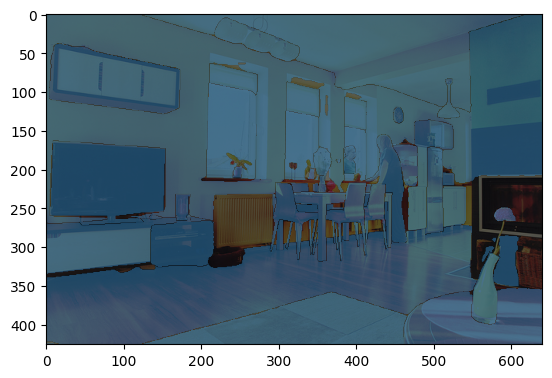

In [5]:
image, layers, instances_info = next(data_iter)

print(image.shape)
print(layers.shape)
print(instances_info)
visualize_mask(image, layers, instances_info, alpha=0.5)


In [6]:
print(instances_info)

{0: InstanceInfo(mapping=(0, 1), parent=None, children=[], node_level=0), 1: InstanceInfo(mapping=(1, 2), parent=None, children=[], node_level=0), 2: InstanceInfo(mapping=(2, 3), parent=None, children=[], node_level=0), 3: InstanceInfo(mapping=(3, 4), parent=None, children=[], node_level=0), 4: InstanceInfo(mapping=(4, 5), parent=None, children=[], node_level=0), 5: InstanceInfo(mapping=(5, 6), parent=None, children=[], node_level=0), 6: InstanceInfo(mapping=(6, 7), parent=None, children=[], node_level=0), 7: InstanceInfo(mapping=(7, 8), parent=None, children=[], node_level=0), 8: InstanceInfo(mapping=(8, 9), parent=None, children=[], node_level=0), 9: InstanceInfo(mapping=(9, 10), parent=None, children=[], node_level=0), 10: InstanceInfo(mapping=(10, 11), parent=None, children=[], node_level=0), 11: InstanceInfo(mapping=(11, 12), parent=None, children=[], node_level=0), 12: InstanceInfo(mapping=(12, 13), parent=None, children=[], node_level=0), 13: InstanceInfo(mapping=(13, 14), paren

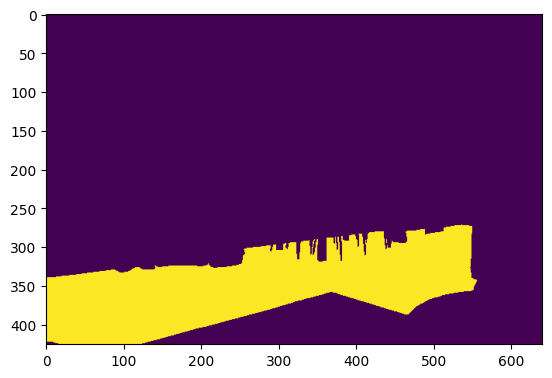

In [7]:
mask = layers[:, :, instances_info[0].mapping[0]]
plt.imshow(mask==instances_info[0].mapping[1])